In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings

# Wyłączamy ostrzeżenia, żeby nie zaśmiecać notatnika
warnings.filterwarnings('ignore')

# Ustawienia stylów dla wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Importy z Twoich plików
from data.loader import load_openml_data
from data.missing_data import generate_mcar, generate_mar1, generate_mar2, generate_mnar
from models.unlabeled_lr import UnlabeledLogReg, run_naive, run_oracle, evaluate



DATASETS = {
    "Spambase": 44,
    "Musk V2": 46615,
    "telescope": 1120,
    "Madelon": 1485
}

def preprocess_after_split(X_train, X_valid, X_test, threshold=0.9):
    """
    Wykonuje preprocesing zabezpieczając przed wyciekiem danych (Data Leakage).
    Fituje transformatory TYLKO na zbiorze treningowym.
    """
    # 1. Imputacja braków na podstawie średnich z TRAIN
    imputer = SimpleImputer(strategy='mean')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_valid_imp = pd.DataFrame(imputer.transform(X_valid), columns=X_valid.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # 2. Usuwanie kolinearnych zmiennych na podstawie korelacji w TRAIN
    corr_matrix = X_train_imp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    
    X_train_red = X_train_imp.drop(columns=to_drop)
    X_valid_red = X_valid_imp.drop(columns=to_drop)
    X_test_red = X_test_imp.drop(columns=to_drop)

    # 3. Skalowanie danych (parametry z TRAIN)
    scaler = StandardScaler()
    X_train_scl = pd.DataFrame(scaler.fit_transform(X_train_red), columns=X_train_red.columns)
    X_valid_scl = pd.DataFrame(scaler.transform(X_valid_red), columns=X_valid_red.columns)
    X_test_scl = pd.DataFrame(scaler.transform(X_test_red), columns=X_test_red.columns)

    return X_train_scl, X_valid_scl, X_test_scl

In [ ]:
results = []

for ds_name, ds_id in DATASETS.items():
    print(f"\n--- Przetwarzanie: {ds_name} (ID: {ds_id}) ---")
    
    X, y = load_openml_data(ds_id)

    # Podział danych PRZED preprocesingiem: 60% Train, 20% Valid, 20% Test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_valid, y_true_train, y_valid = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    )

    # Właściwy preprocesing (fitowanie tylko na X_train)
    X_train, X_valid, X_test = preprocess_after_split(X_train, X_valid, X_test)

    # 1. ORACLE
    oracle_metrics = run_oracle(X_train, y_true_train, X_valid, y_valid, X_test, y_test)
    res_oracle = {
        "Dataset": ds_name, "Scheme": "Oracle", "Parameter": 0.0, 
        "Actual_Missing_Rate": 0.0, "Method": "Oracle"
    }
    res_oracle.update(oracle_metrics)
    results.append(res_oracle)

    # 2. Scenariusze brakujących danych
    scenarios = []

    # MCAR: Zmienne 'c' (prawdopodobieństwo braku danych S=1)
    for c in [0.1, 0.3, 0.5, 0.7, 0.9]:
        y_obs = generate_mcar(X_train, y_true_train, obs_rate=(1.0 - c))
        scenarios.append(('MCAR', c, y_obs))

    # MAR1, MAR2, MNAR - po jednym bazowym wariancie do ogólnego porównania
    y_obs_mar1 = generate_mar1(X_train, y_true_train, bias=0.0)
    scenarios.append(('MAR1', 'default', y_obs_mar1))

    y_obs_mar2 = generate_mar2(X_train, y_true_train, bias=-0.5)
    scenarios.append(('MAR2', 'default', y_obs_mar2))

    y_obs_mnar = generate_mnar(X_train, y_true_train, base_obs_rate=0.5, gamma=3.0)
    scenarios.append(('MNAR', 'default', y_obs_mnar))

    # 3. Ewaluacja modeli dla każdego scenariusza
    for scheme_name, param, y_obs_train in tqdm(scenarios, desc=f"Scenariusze dla {ds_name}"):
        actual_missing_rate = (y_obs_train == -1).mean()

        naive_metrics = run_naive(X_train, y_obs_train, X_valid, y_valid, X_test, y_test)
        
        model_lp = UnlabeledLogReg(completion="label_prop_cne", lp_kernel="knn", lp_n_neighbors=5)
        model_lp.fit(X_train, y_obs_train, X_valid, y_valid)
        lp_metrics = evaluate(y_test, model_lp.predict_proba(X_test))

        model_sp = UnlabeledLogReg(completion="sportisse_em")
        model_sp.fit(X_train, y_obs_train, X_valid, y_valid)
        sp_metrics = evaluate(y_test, model_sp.predict_proba(X_test))

        for method_name, metrics in [
            ("Naive", naive_metrics),
            ("LabelProp_CNe", lp_metrics),
            ("Sportisse_EM", sp_metrics)
        ]:
            res = {
                "Dataset": ds_name, "Scheme": scheme_name, "Parameter": param,
                "Actual_Missing_Rate": actual_missing_rate, "Method": method_name
            }
            res.update(metrics)
            results.append(res)

# Zapisanie wyników
df_results = pd.DataFrame(results)
df_results.to_csv("task3_results.csv", index=False)
print("Zapisano wyniki do task3_results.csv")


--- Przetwarzanie: Musk V2 (ID: 46615) ---


Scenariusze dla Musk V2:   0%|          | 0/8 [00:00<?, ?it/s]

In [7]:
# Wczytanie wyników (dzięki temu możesz zamknąć notatnik i wrócić tu później bez liczenia na nowo)
df = pd.read_csv("task3_results.csv")

# Szybki podgląd na scenariusze inne niż MCAR
other_schemes = df[df['Scheme'].isin(['MAR1', 'MAR2', 'MNAR'])]
display(other_schemes.groupby(['Dataset', 'Scheme', 'Method'])[['roc_auc', 'balanced_accuracy']].mean().round(4))

roc_auc  balanced_accuracy
Dataset Scheme Method                                   
Musk V2 MAR1   LabelProp_CNe   0.9410             0.8126
               Naive           0.9451             0.8415
               Sportisse_EM    0.9283             0.6140
        MAR2   LabelProp_CNe   0.9276             0.7866
               Naive           0.9298             0.8211
               Sportisse_EM    0.9013             0.5049
        MNAR   LabelProp_CNe   0.9211             0.7580
               Naive           0.9399             0.7815
               Sportisse_EM    0.9230             0.5000

Wizualizacje

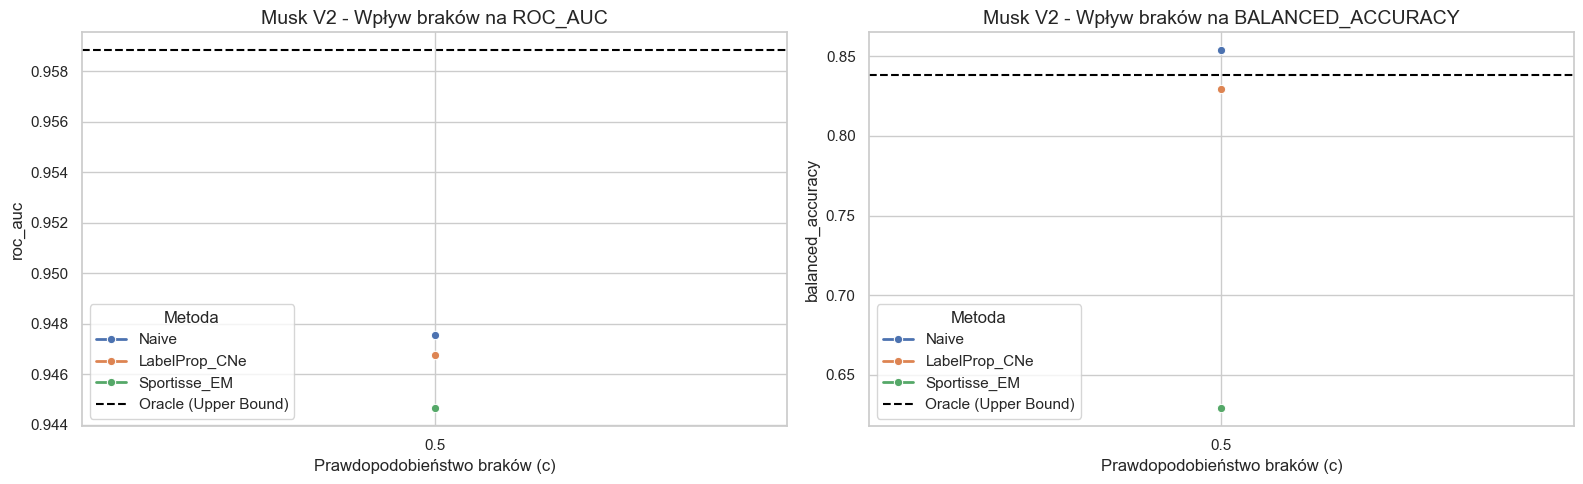

In [8]:
# Analiza wpływu parametru 'c' dla MCAR
mcar_data = df[df['Scheme'].isin(['MCAR', 'Oracle'])].copy()
datasets = mcar_data['Dataset'].unique()
metrics_to_plot = ['roc_auc', 'balanced_accuracy']

fig, axes = plt.subplots(len(datasets), 2, figsize=(16, 5 * len(datasets)))

for i, ds in enumerate(datasets):
    ds_data = mcar_data[mcar_data['Dataset'] == ds]
    
    for j, metric in enumerate(metrics_to_plot):
        ax = axes[i, j] if len(datasets) > 1 else axes[j]
        
        # Rysujemy linie tylko dla metod testowych w MCAR
        sns.lineplot(
            data=ds_data[ds_data['Scheme'] == 'MCAR'], 
            x='Parameter', 
            y=metric, 
            hue='Method', 
            marker='o',
            linewidth=2,
            ax=ax
        )
        
        # Oracle wyciągamy jako pojedynczą wartość i rysujemy jako poziomą linię odniesienia
        oracle_val = ds_data[ds_data['Method'] == 'Oracle'][metric].values[0]
        ax.axhline(oracle_val, ls='--', color='black', label='Oracle (Upper Bound)', zorder=0)
        
        ax.set_title(f"{ds} - Wpływ braków na {metric.upper()}", fontsize=14)
        ax.set_xlabel("Prawdopodobieństwo braków (c)", fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.legend(title="Metoda")

plt.tight_layout()
plt.show()